# YoloE Demo on License Driver

In [1]:
import cv2
import io
import requests
from pathlib import Path
from PIL import Image

from ultralytics.models.yolo.yoloe import YOLOEVPSegPredictor
from ultralytics import YOLOE
import numpy as np
import matplotlib.pyplot as plt

# Model with set class
model = YOLOE("yoloe-26x-seg.pt")
model.set_classes(["book"])

# Model with visual prompts, do not set classes
model_visual = YOLOE("yoloe-26x-seg.pt")

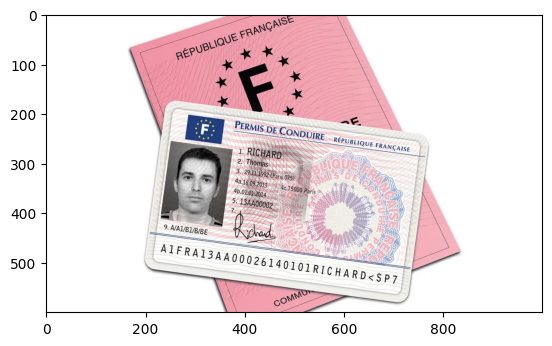

In [2]:
plt.imshow(
    Image.open("french_permis.png")
)

In [3]:
def yolo_predict_visual_prompt(source, conf=0.8):
    # True bbox of french license driver above
    visual_prompts = dict(
        bboxes=np.array([[193.0984, 172.0396, 774.4833, 599.1909]]),
        cls=np.array([0]),
    )
    
    return model_visual.predict(
        source,
        refer_image="french_permis.png",
        visual_prompts=visual_prompts,
        predictor=YOLOEVPSegPredictor,
        conf=conf,
    )

def yolo_predict_book_class(source, conf=0.8):
    return model.predict(
        source,
        predictor=YOLOEVPSegPredictor,
        conf=conf,
    )

In [4]:
# Let's check the prediction works correctly
# when target image is the same than reference image

results = yolo_predict_visual_prompt("french_permis.png")

Ultralytics 8.4.12 🚀 Python-3.13.7 torch-2.10.0+cu128 CPU (AMD Ryzen 5 7535HS with Radeon Graphics)

image 1/1 /home/olivier/Documents/perso/document-ia/french_permis.png: 384x640 1 object0, 996.3ms
Speed: 2.7ms preprocess, 996.3ms inference, 11.1ms postprocess per image at shape (1, 3, 384, 640)


In [5]:
def segment_and_crop(results):
    crops = []
    for result in results:
        img = np.copy(result.orig_img)

        # Iterate each object contour
        for detected_object in result:
            background_mask = np.zeros(img.shape[:2], np.uint8)

            # Create contour mask 
            contour = detected_object.masks.xy.pop().astype(np.int32).reshape(-1, 1, 2)
            # -1 represents contourIdx. If the value is negative, all contours are drawn
            cv2.drawContours(background_mask, [contour], -1, (255, 255, 255), cv2.FILLED)

            # Isolate object with transparent background (when saved as PNG)
            isolated = np.dstack([img, background_mask])

            # detection crop
            x1, y1, x2, y2 = detected_object.boxes.xyxy.cpu().numpy().squeeze().astype(np.int32)
            iso_crop = isolated[y1:y2, x1:x2]

            # Remove alpha channel, use white background
            alpha = iso_crop[:, :, 3] / 255.0
            rgb = iso_crop[:, :, :3]

            white = np.ones_like(rgb) * 255
            out = (rgb * alpha[..., None] + white * (1 - alpha[..., None])).astype(np.uint8)
            crops.append(out)

    return crops

crops = segment_and_crop(results)

In [6]:
crops[0].shape

(427, 581, 3)

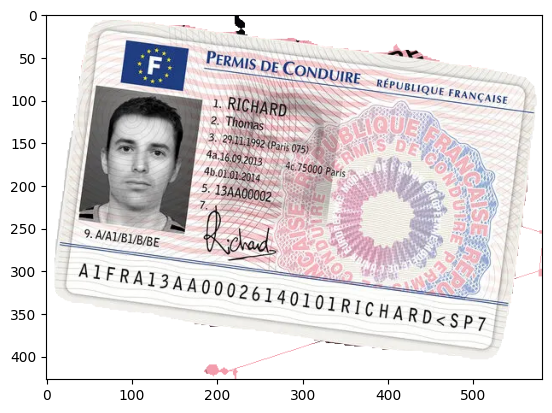

In [7]:
plt.imshow(
    cv2.cvtColor(crops[0], cv2.COLOR_BGR2RGB)
)

In [8]:
def rotate(image_bgr, angle_deg):
    h, w = image_bgr.shape[:2]
    M = cv2.getRotationMatrix2D((w/2, h/2), angle_deg, 1.0)
    return cv2.warpAffine(image_bgr, M, (w, h),
                          flags=cv2.INTER_CUBIC,
                          borderMode=cv2.BORDER_CONSTANT,
                          borderValue=(255,255,255))

def estimate_skew_angle_hough(
    image_bgr,
    kernel_size=(40, 3),
    canny_threshold1=50,
    canny_threshold2=150,
    hough_rho=1,
    hough_theta=np.pi / 180,
    hough_threshold=100,
    min_line_length=100,
    max_line_gap=10,
    angle_limit=45,
):
    gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)
    # turns the image into black/white where text becomes white and background black.
    # Otsu automatically picks the threshold based on the image histogram, making it robust to lighting differences.
    bw = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)[1]

    # connecter les caractères en "lignes" (important)
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, kernel_size)
    connected = cv2.morphologyEx(bw, cv2.MORPH_CLOSE, kernel, iterations=1)

    edges = cv2.Canny(connected, canny_threshold1, canny_threshold2)
    lines = cv2.HoughLinesP(
        edges,
        hough_rho,
        hough_theta,
        threshold=hough_threshold,
        minLineLength=min_line_length,
        maxLineGap=max_line_gap,
    )

    angles = []
    if lines is not None:
        for x1, y1, x2, y2 in lines[:, 0]:
            angle = np.degrees(np.arctan2((y2 - y1), (x2 - x1)))

            # we want angles close to horizontal
            if -angle_limit < angle < angle_limit:
                angles.append(angle)

    if not angles:
        angle_deg = 0.0
    else:
        angle_deg = float(np.median(angles))

    return angle_deg

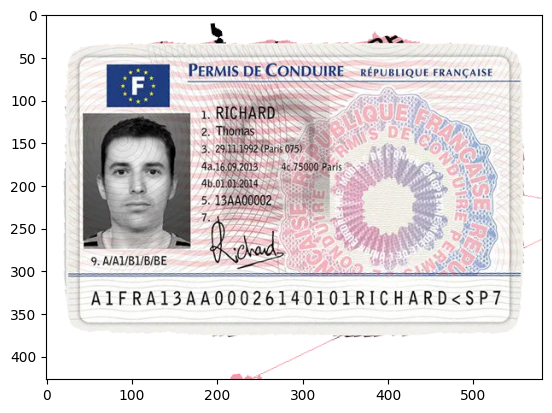

In [9]:
angle = estimate_skew_angle_hough(crops[0])
rotated = rotate(crops[0], angle)
plt.imshow(
    cv2.cvtColor(rotated, cv2.COLOR_BGR2RGB)
)

## Try performance of the re-oriented image with DeepSeek-OCR

In [10]:
cv2.imwrite("rotated.png", rotated)

True

In [11]:
import io
import os
import time
import base64
from openai import OpenAI

def prediction_deep_seek(image):
    _, buffer = cv2.imencode(".png", image)
    io_buf = io.BytesIO(buffer)
    b64_image = base64.b64encode(io_buf.read()).decode("utf-8")

    client = OpenAI(
        base_url=os.environ['OPENAI_BASE_URL'],
        api_key=os.environ['OPENAI_API_KEY'],
        timeout=3600,
    )

    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image_url", "image_url": {"url": f"data:image/png;base64,{b64_image}"}},
                {"type": "text", "text": "Free OCR."},
            ],
        }
    ]
    
    start = time.time()
    response = client.chat.completions.create(
        model="DeepSeek-OCR",
        messages=messages,
        max_tokens=2048,
        temperature=0.0,
        extra_body={
            "skip_special_tokens": False,
            # args used to control custom logits processor
            "vllm_xargs": {
                "ngram_size": 30,
                "window_size": 90,
                # whitelist: <td>, </td>
                "whitelist_token_ids": [128821, 128822],
            },
        },
    )
    print(f"Response costs: {time.time() - start:.2f}s")
    print(f"Generated text:\n\n{response.choices[0].message.content}")

In [14]:
prediction_deep_seek(cv2.imread("rotated.png"))

Response costs: 1.07s
Generated text:

# PERMIS DE CONDUIRE  
**RÉPUBLIQUE FRANÇAISE**  

1. RICHARD  
2. Thomas  
3. 29.11.1992 (Paris 075)  
4a.16.09.2013  
4b.01.01.2014  
5. 13AA00002  

9. A/A1/B1/B/B/E  

**Résultat**  
**RÉSULTAT**  

**A1FRA13AA00026140101RICHARD<SP7**


## Other examples

In [15]:
def save_online_image(url: str) -> Image:    
    response = requests.get(url)
    response.raise_for_status()
    return Image.open(io.BytesIO(response.content))

In [16]:
urls = [
    # Austrian driver license
    "https://globaldocs.store/wp-content/uploads/2025/02/buy-austrian-drivers-license.jpg",
    # French license driver specimen
    "https://media.gettyimages.com/id/180315742/photo/france-driving-license.jpg?s=1024x1024&w=gi&k=20&c=c4Uy_KkNA90a82Izr4_eMBGPzSKu2YoF_cF703cBevk=",
    # UK Driver license
    "https://www.rte.ie/images/0012bbe9-1600.jpg",
    # Another UK Driver license
    "https://blog.aph.com/wp-content/uploads/2015/05/driving-license-header.jpg",
]

In [17]:
for i, url in enumerate(urls):
    img = save_online_image(urls[i])
    img.save(f"online_image{i}.png")

## With reference image

Ultralytics 8.4.12 🚀 Python-3.13.7 torch-2.10.0+cu128 CPU (AMD Ryzen 5 7535HS with Radeon Graphics)

image 1/1 /home/olivier/Documents/perso/document-ia/online_image0.png: 384x640 1 object0, 929.1ms
Speed: 1.6ms preprocess, 929.1ms inference, 1.4ms postprocess per image at shape (1, 3, 384, 640)


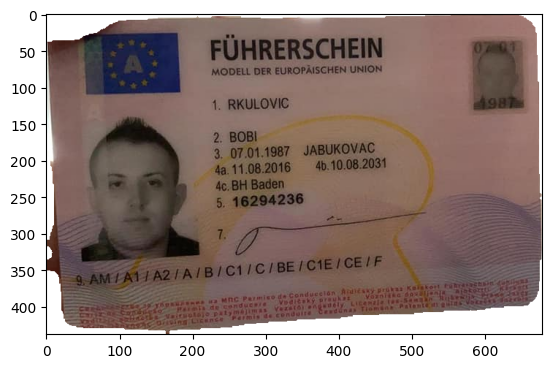

Response costs: 8.03s
Generated text:

FÜHRERSCHEIN  
MODELL DER EUROPÄISCHEN UNION  

1. RKULOVIC  
2. BOBI  
3. 07.01.1987  JABUKOVAC  
4a. 11.08.2016  4b. 10.08.2031  
4c. BH Baden  
5. 16294236  

7.  

9. AM/A1/A2/A/B/C1/C/BE/C1E/CE/F  

Cercavo yopazanne na MNC Parimiso de Conduccion Anticorrupcion y Prohaz Karkori Fuerzas Armadas de la Comandancia de Conduccion y Voz de la Comandancia de la Comandancia de la Comandancia de la Comandancia de la Comandancia de la Comandancia de la Comandanza de la Comandancia de la Comandancia de la Comandancia de la Comandancia de la Comandancia de la Comandantia de la Comandancia de la Comandancia de la Comandancia de la Comandancia de la Comandancia de la Comandancia de la Comandanza de la Comandancia de la Comandancia de la Comandancia de la Comandancia de la Comandancia de la Comandantia de la Comandancia de la Comandancia de la Comandancia de la Comandancia de la Comandancia de la Comandancia de la Comandanza de la Comandancia de la Comandan

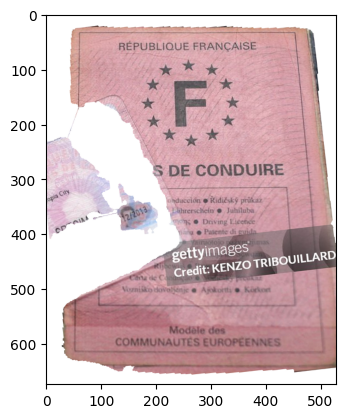

Response costs: 1.00s
Generated text:

RÉPUBLIQUE FRANCAISE

F

S DE CONDUIRE

12/2013

- éducation
- Ridičský průkaz
- Élhrerschein
- Juhiluba
- Driving Licence
- Patient de guida

Credit: KENZO TRIBOUILLARD

- Nizhko dovoljenje
- Ankorth
- Korkort

Modele des  
COMMUNAUTÉS EUROPEENNES
None
Ultralytics 8.4.12 🚀 Python-3.13.7 torch-2.10.0+cu128 CPU (AMD Ryzen 5 7535HS with Radeon Graphics)

image 1/1 /home/olivier/Documents/perso/document-ia/online_image2.png: 384x640 1 object0, 960.1ms
Speed: 1.9ms preprocess, 960.1ms inference, 1.1ms postprocess per image at shape (1, 3, 384, 640)


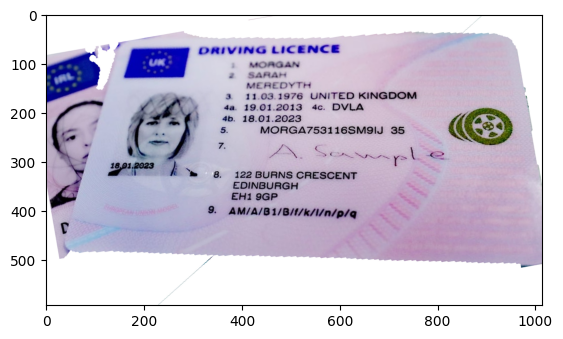

Response costs: 1.20s
Generated text:

DRIVING LICENSE

1. MORGAN
2. SARAH
   MEREDYTH

3. 11.03.1976 UNITED KINGDOM
4a. 19.01.2013 4c. DVLA
4b. 18.01.2023

5. MORGA753116SM9IJ 35

7. A. Scarfe

8. 122 BURNS CRESCENT
   EDINBURGH
   EH1 9GP

9. AM/A/B1/B/1/k/1/n/p/q
None
Ultralytics 8.4.12 🚀 Python-3.13.7 torch-2.10.0+cu128 CPU (AMD Ryzen 5 7535HS with Radeon Graphics)

image 1/1 /home/olivier/Documents/perso/document-ia/online_image3.png: 384x640 1 object0, 999.8ms
Speed: 1.4ms preprocess, 999.8ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)


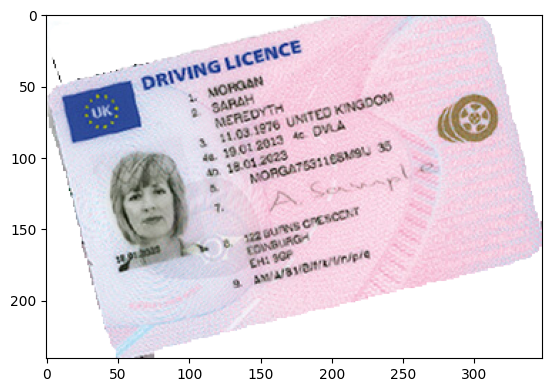

Response costs: 0.77s
Generated text:

DRIVING LICENCE

MORGAN  
SARAH  
MEREDYTH  
UNITED KINGDOM  

1. 11.03.1976  
2. 19.01.2013  
3. 18.01.2023  
4. 18.01.2023  
5.  
6.  
7.  
8.  
9.  

A. Connolly  
122 GUINNESS CRESCENT  
EDINBURGH  
EH1 9QP  
AM/A/B1/D1/UK/UN/JP/GE
None


In [18]:
for i in range(len(urls)):
    results = yolo_predict_visual_prompt(f"online_image{i}.png", conf=0.6)
    crops = segment_and_crop(results)
    for j, crop in enumerate(crops):
        angle = estimate_skew_angle_hough(crop)
        rotated = rotate(crop, angle)
        plt.imshow(
            cv2.cvtColor(rotated, cv2.COLOR_BGR2RGB)
        )
        plt.show()
        cv2.imwrite(f"rotated_online_image{i}_j.png", rotated)
        print(prediction_deep_seek(rotated))
    print("=====================")

## With class `book`


image 1/1 /home/olivier/Documents/perso/document-ia/online_image0.png: 384x640 1 book, 1147.3ms
Speed: 2.2ms preprocess, 1147.3ms inference, 1.3ms postprocess per image at shape (1, 3, 384, 640)
(438, 679, 3)
Angle: 0.0


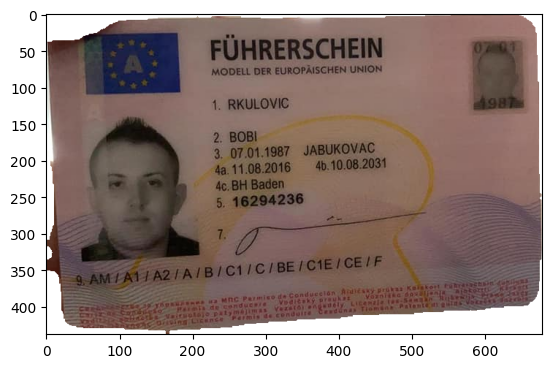


image 1/1 /home/olivier/Documents/perso/document-ia/online_image1.png: 448x640 2 books, 1012.9ms
Speed: 2.6ms preprocess, 1012.9ms inference, 0.8ms postprocess per image at shape (1, 3, 448, 640)
(674, 528, 3)
Angle: 6.519801751656986


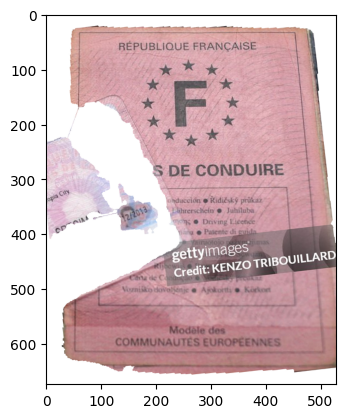

(445, 582, 3)
Angle: -16.928045746014654


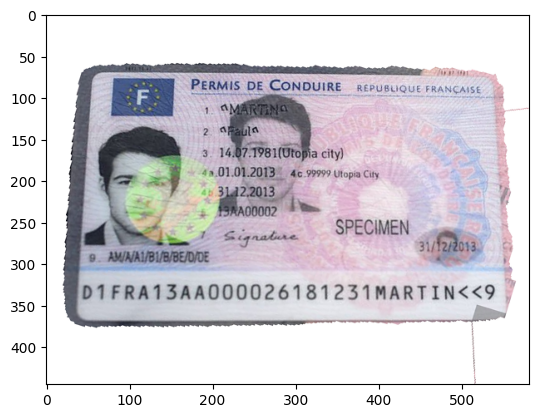


image 1/1 /home/olivier/Documents/perso/document-ia/online_image2.png: 384x640 2 books, 671.6ms
Speed: 1.3ms preprocess, 671.6ms inference, 0.8ms postprocess per image at shape (1, 3, 384, 640)
(890, 1587, 3)
Angle: 9.979303244696471


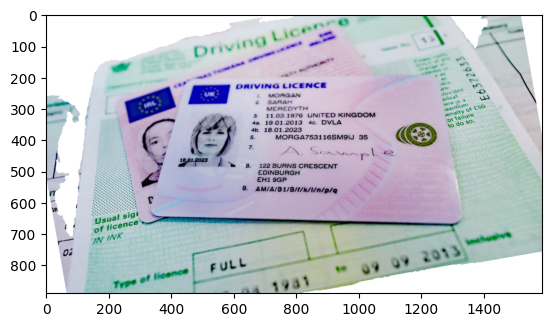

(593, 1018, 3)
Angle: 9.914364095402966


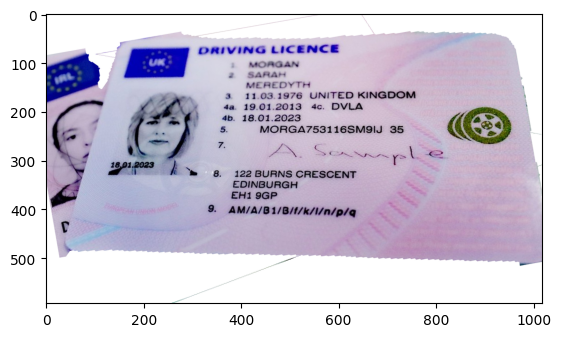


image 1/1 /home/olivier/Documents/perso/document-ia/online_image3.png: 384x640 1 book, 663.6ms
Speed: 1.0ms preprocess, 663.6ms inference, 0.7ms postprocess per image at shape (1, 3, 384, 640)
(241, 348, 3)
Angle: 0.0


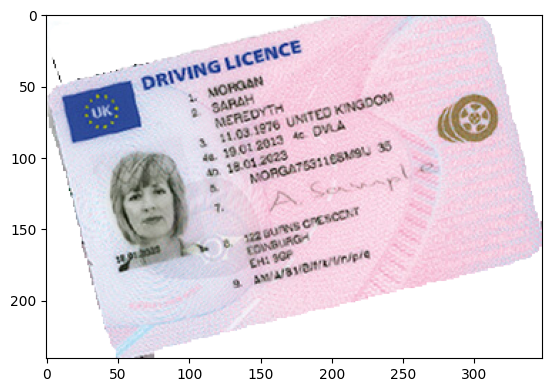

In [21]:
for i in range(len(urls)):
    results = yolo_predict_book_class(f"online_image{i}.png", conf=0.3)
    crops = segment_and_crop(results)
    for j, crop in enumerate(crops):
        print(crop.shape)
        angle = estimate_skew_angle_hough(crop)
        print("Angle:", angle)
        rotated = rotate(crop, angle)
        plt.imshow(
            cv2.cvtColor(rotated, cv2.COLOR_BGR2RGB)
        )
        plt.show()
        cv2.imwrite(f"rotated_online_image{i}_j.png", rotated)
    print("=====================")